In [1]:
# General Libraries
import numpy as np  # For numerical computations and operations
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating static visualizations
import missingno as msno  # For visualizing missing data in the dataset
import seaborn as sns  # For advanced statistical data visualization
import plotly.express as px  # For interactive visualizations and exploratory analysis
import re  # For working with regular expressions (pattern matching)
import os  # For interacting with the operating system (file and directory handling)
import warnings  # For managing warning messages in Python (e.g., suppressing warnings)
# warnings.filterwarnings("ignore", category=FutureWarning) # Suppress FutureWarnings, which are warnings about features that will be deprecated in future versions

In [14]:
# Fill missing values in the "name" column with the mode of each customer group.
df1["name"] = df1.groupby("customer_id")["name"].transform(
    lambda x: x.fillna(x.mode()[0]))

# Check if each customer group in "name" has exactly 8 observations.
(df1.groupby("customer_id")["name"].count() == 8).all()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\3993766508.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["name"] = df1.groupby("customer_id")["name"].transform(


True

## AGE

In [17]:
# Clean up the "age" column by removing spaces, hyphens, and underscores.
df1['age'] = df1['age'].str.replace(' ', '').str.replace('-', '').str.replace('_', '')

# Convert the "age" column to numeric values, downcasting to the smallest integer type.
df1["age"] = pd.to_numeric(df1["age"], downcast="integer")

# Check the data type of the "age" column.
df1["age"].dtype

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\3744731189.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['age'] = df1['age'].str.replace(' ', '').str.replace('-', '').str.replace('_', '')
C:\Users\USER\AppData\Local\Temp\ipykernel_17392\3744731189.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["age"] = pd.to_numeric(df1["age"], downcast="integer")


dtype('int16')

In [20]:
# Set "age" values less than 20 or greater than 56 to missing (pd.NA)
df1.loc[(df1["age"] < 20) | (df1["age"] > 56), "age"] = pd.NA

# Fill missing "age" values within each customer group using forward fill and backward fill
df1["age"] = df1.groupby("customer_id")["age"].transform(
    lambda x: x.ffill().bfill()
)

# Count the number of missing "age" values
df1["age"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\2342629590.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["age"] = df1.groupby("customer_id")["age"].transform(


10360

- Based on the output, there are **4 values** greater than 56, which can be considered outliers. Therefore, we filtered the data to include only values up to 56.

- **A limit of 20 years** can be set as the minimum age for being employed or eligible for a credit card. Therefore, any values under 20 years will be assigned as missing values.

In [21]:
# Fill missing "age" values with the median of the "age" column.
df1["age"].fillna(df1["age"].median(), inplace=True)

# Count the number of missing "age" values.
df1["age"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\2383353316.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["age"].fillna(df1["age"].median(), inplace=True)


0

In [24]:
# Mark invalid SSN values as NaN
df1['ssn'] = df1['ssn'].replace('#F%$D@*&8', np.nan)

# Group by "customer_id" and fill missing SSNs with the most frequent value within each group
df1['ssn'] = df1.groupby('customer_id')['ssn'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)

# Display the number of missing SSN values
df1["ssn"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\603920273.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['ssn'] = df1['ssn'].replace('#F%$D@*&8', np.nan)
C:\Users\USER\AppData\Local\Temp\ipykernel_17392\603920273.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['ssn'] = df1.groupby('customer_id')['ssn'].transform(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)


0

In [25]:
df1.ssn.value_counts()

ssn
821-00-0265    8
544-05-0223    8
381-36-5261    8
994-73-1178    8
647-44-9598    8
              ..
936-12-2774    8
091-61-1869    8
576-38-5212    8
281-30-1712    8
078-73-5990    8
Name: count, Length: 12500, dtype: int64

- Upon further inspection, we observed that for every 8 SSNs, the **customer_id** is consistently 12500. This indicates that the data has been correctly filled and the data imputation process has been done accurately.

## OCCUPATION

In [26]:
df1.occupation.value_counts()

occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64

In [27]:
# Fill "_______" occupation values with the most frequent occupation within each customer group
df1["occupation"] = df1.groupby("customer_id")["occupation"].transform(
    lambda x: x.where(x != "_______", x[x != "_______"].mode().iloc[0]))

# The count of unique occupation values
df1["occupation"].value_counts()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\3447533333.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["occupation"] = df1.groupby("customer_id")["occupation"].transform(


occupation
Lawyer           7096
Engineer         6864
Architect        6824
Mechanic         6776
Scientist        6744
Accountant       6744
Developer        6720
Media_Manager    6720
Teacher          6672
Entrepreneur     6648
Doctor           6568
Journalist       6536
Manager          6432
Musician         6352
Writer           6304
Name: count, dtype: int64

In [28]:
# Count the number of customers with only one unique occupation
(df1.groupby("customer_id")["occupation"].nunique() == 1).sum()  # 12500X8 = 100000

12500

In [31]:
# Fill missing "monthly_inhand_salary" values using forward and backward fill methods within each customer group
df1["monthly_inhand_salary"] = df1.groupby(
    "customer_id")["monthly_inhand_salary"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

# Check the number of missing values in "monthly_inhand_salary"
df1["monthly_inhand_salary"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\3864236729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["monthly_inhand_salary"] = df1.groupby(


0

In [32]:
df1["monthly_inhand_salary"].value_counts().sample(10)

monthly_inhand_salary
7404.390000    8
2000.025000    8
3491.243333    8
2828.394167    8
1570.168333    8
4082.237500    8
1750.080417    8
933.518750     8
3424.231667    8
1123.653333    8
Name: count, dtype: int64

In [33]:
df1["monthly_inhand_salary"] = df["Monthly_Inhand_Salary"]

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\4257476214.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["monthly_inhand_salary"] = df["Monthly_Inhand_Salary"]


In [34]:
# Check the maximum difference between unique monthly_inhand_salary values for each customer
filtered_df = df1.groupby("customer_id")["monthly_inhand_salary"].unique()

# Calculate the maximum difference (max - min) for customers with more than one unique salary
diff = filtered_df.apply(lambda x: np.max(x) - np.min(x) if len(x) > 1 else 0).max()  # Maximum difference is reasonable
print(diff)

df1.groupby("customer_id")["monthly_inhand_salary"].nunique().unique()

1634.2132813235112


array([1, 2], dtype=int64)

- Each group contains a unique customer ID, and the salary should be the same across all entries within the same group. Therefore, we will correct any inconsistent salary values within the groups, ensuring that the salary values are uniform across each group.

In [35]:
# Điền giá trị thiếu trong cột monthly_inhand_salary theo nhóm customer_id
df1["monthly_inhand_salary"] = df1.groupby("customer_id")["monthly_inhand_salary"]\
    .transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\193162017.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["monthly_inhand_salary"] = df1.groupby("customer_id")["monthly_inhand_salary"]\


In [36]:
# # Define the function to fix salary values
# def fix_salary(x):
#     if x.max() - x.min() > 0:  # If there's a significant difference in salaries
#         mode_value = x.mode()[0] if not x.mode().empty else x.median()  # Get mode or median if no mode
#         return x.fillna(mode_value).apply(lambda _: mode_value)  # Fill missing values with mode/median
#     return x  # Return unchanged if no difference

# # Apply the fix_salary function to the monthly_inhand_salary column grouped by customer_id
# df1["monthly_inhand_salary"] = df1.groupby("customer_id")["monthly_inhand_salary"].transform(fix_salary)

In [39]:
# Remove '_' characters from the 'annual_income' column
df1["annual_income"] = df1["annual_income"].str.strip("_")

# Convert the 'annual_income' column to a numeric (integer) format
df1["annual_income"] = pd.to_numeric(df1["annual_income"], downcast="integer")

# Check the data type of the 'annual_income' column
df1["annual_income"].dtype

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\1032513893.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["annual_income"] = df1["annual_income"].str.strip("_")
C:\Users\USER\AppData\Local\Temp\ipykernel_17392\1032513893.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["annual_income"] = pd.to_numeric(df1["annual_income"], downcast="integer")


dtype('float64')

In [40]:
# Display unique annual_income values for each customer group and randomly sample 20 groups
df1.groupby("customer_id")["annual_income"].unique().sample(10)

customer_id
CUS_0xc31a        [74288.45999999999]
CUS_0x4711                 [32430.82]
CUS_0x79d7                 [36319.38]
CUS_0xdca                 [144066.24]
CUS_0x793       [28824.3, 10042124.0]
CUS_0x1dad                [17807.935]
CUS_0x7ea1    [10034.725, 17872695.0]
CUS_0x4a51                 [18885.93]
CUS_0xab2b                 [31985.64]
CUS_0x5911                  [7641.71]
Name: annual_income, dtype: object

In [41]:
# Count the occurrences of each annual_income value within customer groups and summarize their frequency
df1.groupby("customer_id")["annual_income"].value_counts().value_counts()

count
8    11535
1      999
7      933
6       30
5        2
Name: count, dtype: int64

- When we check how many times the same value repeats in the **annual_income** column for each customer group **customer_id**, we observe occurrences such as 1, 7, 6, and 5. This indicates that there are values within the customer groups that need correction. Under normal circumstances, we should see a consistent value of **12500** for each customer group, as expected from the calculation (8 * 12500 = 100,000).

In [42]:
# Check the difference between annual income and the product of monthly salary times 12
df1[df1["annual_income"] != df1["monthly_inhand_salary"] * 12]

,id,customer_id,month,name,age,credit_history_age,ssn,occupation,annual_income,monthly_inhand_salary,total_emi_per_month
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23.0,22 Years and 1 Months,821-00-0265,Scientist,19114.12,1824.843333,49.574949
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23.0,NaN,821-00-0265,Scientist,19114.12,1824.843333,49.574949
2,0x1604,CUS_0xd40,March,Aaron Maashoh,23.0,22 Years and 3 Months,821-00-0265,Scientist,19114.12,1824.843333,49.574949
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23.0,22 Years and 4 Months,821-00-0265,Scientist,19114.12,1824.843333,49.574949
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23.0,22 Years and 5 Months,821-00-0265,Scientist,19114.12,1824.843333,49.574949
...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25.0,31 Years and 6 Months,078-73-5990,Mechanic,39628.99,3359.415833,35.104023
99996,0x25fea,CUS_0x942c,May,Nicks,25.0,31 Years and 7 Months,078-73-5990,Mechanic,39628.99,3359.415833,35.104023
99997,0x25feb,CUS_0x942c,June,Nicks,25.0,31 Years and 8 Months,078-73-5990,Mechanic,39628.99,3359.415833,35.104023
99998,0x25fec,CUS_0x942c,July,Nicks,25.0,31 Years and 9 Months,078-73-5990,Mechanic,39628.99,3359.415833,35.104023


In [43]:
# Filter rows where annual income is greater than monthly salary * 18
filtered_df = df1[df1["annual_income"] > df1["monthly_inhand_salary"] * 18]

- The reason for taking 18 times the monthly income is to account for potential increases due to bonuses or additional income. This represents the maximum possible increase and is set as a **critical threshold**, equivalent to 1.5 times the annual income.

In [44]:
# Calculate the mode of 'annual_income' for each customer
filtered_df = df1.groupby("customer_id")["annual_income"].agg(
    lambda x: x.mode().iloc[0])

# Replace 'annual_income' values if they exceed 1.5 years' worth of 'monthly_inhand_salary',
# with the mode value calculated for each customer.
df1.loc[df1["annual_income"] > df1["monthly_inhand_salary"] * 18,
        "annual_income"] = df1["customer_id"].map(filtered_df)

In [45]:
df1.groupby("customer_id")["annual_income"].value_counts().value_counts()
#all annual_income values of customers are one unique value

count
8    12500
Name: count, dtype: int64

In [48]:
# Step 2: Replace 'total_emi_per_month' values with the most frequent value for each 'customer_id'
# We will first find the mode for each customer and use it to replace the values
df1['total_emi_per_month'] = df1.groupby('customer_id')['total_emi_per_month'].transform(
    lambda x: x.mode().iloc[0])

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\975443285.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['total_emi_per_month'] = df1.groupby('customer_id')['total_emi_per_month'].transform(


In [49]:
df1.groupby("customer_id")["total_emi_per_month"].value_counts().value_counts()

count
8    12500
Name: count, dtype: int64

In [50]:
#The value of total_emi_per_month is typically around 30%-40% of the monthly income.
df1.loc[df1["total_emi_per_month"] > df1["monthly_inhand_salary"] * 0.3].count()

id                       0
customer_id              0
month                    0
name                     0
age                      0
credit_history_age       0
ssn                      0
occupation               0
annual_income            0
monthly_inhand_salary    0
total_emi_per_month      0
dtype: int64

In [62]:
# Function to fill missing credit history values randomly
def fill_missing_credit_history(row):
    """
    Fills missing credit history values randomly based on age:
    - <25 years: Maximum 6*12 months.
    - 25-35 years: Maximum 16*12 months.
    - 35-45 years: Maximum 26*12 months.
    - 45+ years: Maximum 38*12 months.
    """
    # Mean and standard deviation for random value generation
    mean = 2200  # Mean value
    std_dev = 1000  # Standard deviation

    # Dictionary to store maximum months based on age ranges
    age_limits = {
        (0, 20): 6 * 12,  # For ages <= 20, max 72 months
        (20, 30): 12 * 12,  # For ages 20-30, max 144 months
        (30, 40): 18 * 12,  # For ages 30-40, max 216 months
        (40, 50): 24 * 12,  # For ages 40-50, max 288 months
        (50, float('inf')): 30 * 12  # For ages 50+, max 360 months
    }

    if pd.isna(row['credit_history_age']):  # Process only for missing values
        age_in_months = row['age'] * 12  # Convert age to months

        # Select the maximum months based on age
        for age_range, max_months in age_limits.items():
            if age_range[0] <= row['age'] < age_range[1]:
                break

        # Choose a random value from a normal distribution
        random_value = int(np.random.normal(loc=mean, scale=std_dev))

        # Check the conditions: The selected random value should fit the age range
        # and the difference between age and credit history should be at least 216 months
        while not (0 <= random_value <= max_months and (age_in_months - random_value) >= 216):
            random_value = int(np.random.normal(loc=mean, scale=std_dev))  # Generate a new random value

        return random_value
    else:
        return row['credit_history_age']  # Keep non-missing values unchanged

-  
This script fills the missing credit_history_age values randomly based on the age of the person. First, it defines a specific maximum credit history duration (in months) for each age group, based on age. If a person's credit_history_age value is missing, it determines the appropriate maximum value based on age and randomly generates this value using a normal distribution. The generated random value must match the age and ensure that the difference between age and credit history is at least 216 months. A random value is generated again until a value meeting these conditions is found and then the missing field is filled with this value. The script only processes the missing data and keeps all other data intact.

In [63]:
# Applying the function to the DataFrame
df1['credit_history_age'] = df1.apply(fill_missing_credit_history, axis=1)

In [64]:
df1.drop('critic_kontrol', axis=1, inplace=True) #We had written the **critic_kontrol** function earlier, but it is no longer necessary.

In [71]:
# Replace invalid 'num_bank_accounts' values (<0 or >11) with NaN.
df2.loc[(df2["num_bank_accounts"] < 0) | (df2["num_bank_accounts"] > 11),
        "num_bank_accounts"] = pd.NA

# Fill NaN values in 'num_bank_accounts' within each 'customer_id' group:
# - Forward-fill (ffill) fills NaN with the previous valid value.
# - Backward-fill (bfill) fills NaN with the next valid value if no previous value exists.
df2["num_bank_accounts"] = df2.groupby(
    "customer_id")["num_bank_accounts"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

# Count and return the number of remaining NaN values in 'num_bank_accounts'.
df2["num_bank_accounts"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\3529881688.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["num_bank_accounts"] = df2.groupby(


0

In [74]:
# Replace 'num_credit_card' values greater than 11 with NaN.
df2.loc[df2["num_credit_card"] > 10, "num_credit_card"] = pd.NA

# Fill NaN values in 'num_credit_card' within each 'customer_id' group:
# - Forward-fill (ffill) uses the previous valid value.
# - Backward-fill (bfill) uses the next valid value if no previous value exists.
df2["num_credit_card"] = df2.groupby(
    "customer_id")["num_credit_card"].transform(
        lambda x: x.fillna(method="ffill").fillna(method="bfill"))

# Count and return the number of remaining NaN values in 'num_credit_card'.
df2["num_credit_card"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\1830297524.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["num_credit_card"] = df2.groupby(


0

-  Therefore, we will clean all values beyond **10** to maintain consistency in the data.

In [77]:
# Replace outlier values in 'interest_rate' greater than 34 with NaN
df2.loc[df2["interest_rate"] > 34, "interest_rate"] = pd.NA

# Fill missing values in 'interest_rate' with the mode (most frequent value) within each 'customer_id' group
df2["interest_rate"] = df2.groupby("customer_id")["interest_rate"].transform(
    lambda x: x.fillna(x.mode()[0]))

# Check the count of remaining NaN values in 'interest_rate'
df2["interest_rate"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\2947012822.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["interest_rate"] = df2.groupby("customer_id")["interest_rate"].transform(


0

In [78]:
# Group by 'customer_id' and count the number of unique 'interest_rate' values for each group
# Check where the count of unique values equals 2, and sum these cases to get the total count
(df2.groupby("customer_id")["interest_rate"].nunique() == 2).sum()

0

- Here, we need to check whether there are two different values within each **customer_id**. If such discrepancies exist, we must separate and clean these inconsistent entries to ensure data integrity.

In [81]:
# Strips the underscore character ("_") from the values in the 'num_of_loan' column
df2["num_of_loan"] = df2["num_of_loan"].str.strip("_")

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\2565364137.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["num_of_loan"] = df2["num_of_loan"].str.strip("_")


In [82]:
# Converts the 'num_of_loan' column to numeric values, downcasting to integers for memory optimization
df2["num_of_loan"] = pd.to_numeric(df2["num_of_loan"], downcast="integer")

# Displays the data type of the 'num_of_loan' column after conversion
df2["num_of_loan"].dtype

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\4178030911.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["num_of_loan"] = pd.to_numeric(df2["num_of_loan"], downcast="integer")


dtype('int16')

In [84]:
# Marks invalid values in 'num_of_loan' (values < 0 or > 9) as NaN
df2.loc[(df2["num_of_loan"] < 0) | (df2["num_of_loan"] > 9), "num_of_loan"] = pd.NA

# Fills missing values in 'num_of_loan' within each 'customer_id' group using forward and backward fill methods
df2["num_of_loan"] = df2.groupby("customer_id")["num_of_loan"].transform(
    lambda x: x.fillna(method="ffill").fillna(method="bfill"))

# Counts the number of remaining NaN values in the 'num_of_loan' column
df2["num_of_loan"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\1119825236.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["num_of_loan"] = df2.groupby("customer_id")["num_of_loan"].transform(


0

In [88]:
# Counts the number of customers where the 'type_of_loan' is missing (NaN).
df2[df2["type_of_loan"].isna()]["customer_id"].count()

11408

In [89]:
(df2["num_of_loan"] == 0).sum()

11408

In [90]:
# Updates the 'type_of_loan' column to "No Loan" for customers who have 0 loans.
df2.loc[df2["num_of_loan"] == 0, "type_of_loan"] = "No Loan"

- If an individual has no loans (**num_of_loan = 0**), explicitly marking this as **"No Loan"** enhances clarity during data analysis and ensures the information is easily understood.

In [91]:
df2["type_of_loan"].isna().sum()

0

In [92]:
# Removes the string " and" from the 'type_of_loan' column without using regular expressions.
df2["type_of_loan"] = df2["type_of_loan"].str.replace(" and", "", regex=False)

# Splits the 'type_of_loan' column by ", " to create a list of loan types for each row.
df2["type_of_loan"] = df2["type_of_loan"].str.split(", ")

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\1899216096.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["type_of_loan"] = df2["type_of_loan"].str.replace(" and", "", regex=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_17392\1899216096.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["type_of_loan"] = df2["type_of_loan"].str.split(", ")


- To improve the clarity and observation during data counting, we remove the **And** expression and use commas for counting. This allows for better separation and easier analysis of the data.

In [93]:
df2["type_of_loan"].value_counts().sample(10)

type_of_loan
[Credit-Builder Loan, Home Equity Loan, Auto Loan, Personal Loan]                                                      8
[Home Equity Loan, Not Specified, Mortgage Loan, Personal Loan, Auto Loan, Not Specified, Student Loan]                8
[Credit-Builder Loan, Payday Loan, Debt Consolidation Loan]                                                            8
[Home Equity Loan, Debt Consolidation Loan, Credit-Builder Loan, Credit-Builder Loan]                                  8
[Home Equity Loan, Not Specified, Personal Loan, Not Specified, Personal Loan]                                         8
[Credit-Builder Loan, Home Equity Loan, Auto Loan, Auto Loan, Payday Loan]                                             8
[Debt Consolidation Loan, Auto Loan, Home Equity Loan, Mortgage Loan, Personal Loan, Not Specified, Personal Loan]     8
[Personal Loan, Credit-Builder Loan, Debt Consolidation Loan, Student Loan]                                            8
[Debt Consolidation

In [94]:
# Examining unique loan types

unique_loans = set()  # Initialize an empty set to store unique loan types.

# Iterate through each row in the 'type_of_loan' column.
for loans in df2["type_of_loan"]:

    # Iterate through each loan type in the list.
    for loan in loans:

        # Split each loan by comma and remove any extra spaces using strip().
        loan_items = [item.strip() for item in loan.split(",")]

        # Add each unique loan item to the set.
        unique_loans.update(loan_items)

# Sort the unique loan types in alphabetical order.
unique_loans = sorted(unique_loans)

# Display the sorted unique loan types.
unique_loans

['Auto Loan',
 'Credit-Builder Loan',
 'Debt Consolidation Loan',
 'Home Equity Loan',
 'Mortgage Loan',
 'No Loan',
 'Not Specified',
 'Payday Loan',
 'Personal Loan',
 'Student Loan']

In [105]:
# Stripping underscores from 'num_of_delayed_payment' values
df2["num_of_delayed_payment"] = df2["num_of_delayed_payment"].str.strip("_")

# Converting 'num_of_delayed_payment' to numeric values, downcasting to integer type
df2["num_of_delayed_payment"] = pd.to_numeric(df2["num_of_delayed_payment"],
                                              downcast="integer")

# Checking the data type of 'num_of_delayed_payment' column
df2["num_of_delayed_payment"].dtype

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\3801831300.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["num_of_delayed_payment"] = df2["num_of_delayed_payment"].str.strip("_")
C:\Users\USER\AppData\Local\Temp\ipykernel_17392\3801831300.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["num_of_delayed_payment"] = pd.to_numeric(df2["num_of_delayed_payment"],


dtype('float64')

In [106]:
# Counting the number of missing ('NaN') values in 'num_of_delayed_payment' for each 'customer_id'
df2[df2["num_of_delayed_payment"].isna()].groupby("customer_id").size()

customer_id
CUS_0x1011    2
CUS_0x1013    1
CUS_0x1018    1
CUS_0x102d    1
CUS_0x102e    1
             ..
CUS_0xfdd     1
CUS_0xfe3     3
CUS_0xfe4     2
CUS_0xff6     1
CUS_0xffd     1
Length: 5465, dtype: int64

In [108]:
# Handling out-of-range values for 'num_of_delayed_payment'
df2.loc[(df2["num_of_delayed_payment"] < 0) | (df2["num_of_delayed_payment"] > 28), "num_of_delayed_payment"] = np.nan

# Filling missing values (NaN) within each 'customer_id' group using forward and backward fill
df2["num_of_delayed_payment"] = df2.groupby("customer_id")["num_of_delayed_payment"].transform(
    lambda x: x.fillna(method="ffill").fillna(method="bfill"))

# Checking the total number of missing values after filling
df2["num_of_delayed_payment"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\2086566288.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["num_of_delayed_payment"] = df2.groupby("customer_id")["num_of_delayed_payment"].transform(


0

In [111]:
# Replacing "_" values in 'changed_credit_limit' with NaN
df2.loc[(df2["changed_credit_limit"] == "_"), "changed_credit_limit"] = np.nan

# Filling missing values (NaN) within each 'customer_id' group using forward and backward fill
df2["changed_credit_limit"] = df2.groupby("customer_id")["changed_credit_limit"].transform(
    lambda x: x.fillna(method="ffill").fillna(method="bfill"))

# Checking the total number of missing values after filling
df2["changed_credit_limit"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\2093550854.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["changed_credit_limit"] = df2.groupby("customer_id")["changed_credit_limit"].transform(


0

In [112]:
# Convert 'changed_credit_limit' to numeric values (float), downcast to save memory, and round to 3 decimal places
df2["changed_credit_limit"] = pd.to_numeric(df2["changed_credit_limit"],
                                            downcast="float").round(3)

# Check the data type of the 'changed_credit_limit' column after conversion
df2["changed_credit_limit"].dtype
# because it needs to be converted to float value after doing operations as limit object.

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\31616839.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["changed_credit_limit"] = pd.to_numeric(df2["changed_credit_limit"],


dtype('float32')

In [117]:
# Set 'num_credit_inquiries' greater than 17 to NaN
df2.loc[(df2["num_credit_inquiries"] > 17), "num_credit_inquiries"] = pd.NA

# Fill NaN values using forward fill and backward fill within each customer_id group
df2["num_credit_inquiries"] = df2.groupby("customer_id")["num_credit_inquiries"].transform(
    lambda x: x.fillna(method="ffill").fillna(method="bfill"))

# Check how many NaN values are left in 'num_credit_inquiries'
df2["num_credit_inquiries"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\2046192273.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["num_credit_inquiries"] = df2.groupby("customer_id")["num_credit_inquiries"].transform(


0

- Here, we observe outliers after **17**, so we will clean these values to maintain consistency and accuracy in the data.

In [122]:
# Replace "_" values in 'credit_mix' with NaN
df2.loc[df2["credit_mix"] == "_", "credit_mix"] = pd.NA

# Fill NaN values in 'credit_mix' for each customer with the most frequent value (mode)
df2["credit_mix"] = df2.groupby("customer_id")["credit_mix"].transform(
    lambda x: x.fillna(x.mode()[0]))

# Check the number of remaining NaN values in 'credit_mix'
df2["credit_mix"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\3429419070.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["credit_mix"] = df2.groupby("customer_id")["credit_mix"].transform(


0

In [123]:
df2["credit_mix"].isna().sum()

0

In [127]:
# Remove leading and trailing underscores from 'outstanding_debt' values
df2["outstanding_debt"] = df2["outstanding_debt"].str.strip("_")

# Convert 'outstanding_debt' to numeric values and downcast to float for memory optimization
df2["outstanding_debt"] = pd.to_numeric(df2["outstanding_debt"], downcast="float")

# Check the data type of 'outstanding_debt' column
df2["outstanding_debt"].dtype

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\2444587421.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["outstanding_debt"] = df2["outstanding_debt"].str.strip("_")
C:\Users\USER\AppData\Local\Temp\ipykernel_17392\2444587421.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["outstanding_debt"] = pd.to_numeric(df2["outstanding_debt"], downcast="float")


dtype('float32')

In [134]:
# Count the occurrences of each unique value in 'credit_utilization_ratio' column, including NaN values,
# and then sort the result in ascending order by the index (the credit_utilization_ratio values).
df3.credit_utilization_ratio.value_counts(dropna=False).sort_index()

credit_utilization_ratio
20.000000    1
20.100770    1
20.172942    1
20.244130    1
20.257073    1
            ..
49.064277    1
49.254983    1
49.522324    1
49.564519    1
50.000000    1
Name: count, Length: 100000, dtype: int64

In [137]:
# Count occurrences of each unique value in the 'payment_of_min_amount' column, including NaN values
df3.payment_of_min_amount.value_counts(dropna=False)

payment_of_min_amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64

In [138]:
# Grouping the data by 'customer_id' and counting occurrences of each unique value in the 'payment_of_min_amount' column
# including NaN values, for each customer
df3.groupby(["customer_id"]).payment_of_min_amount.value_counts(dropna=False)


customer_id  payment_of_min_amount
CUS_0x1000   Yes                      8
CUS_0x1009   Yes                      7
             NM                       1
CUS_0x100b   No                       7
             NM                       1
                                     ..
CUS_0xff4    Yes                      7
             NM                       1
CUS_0xff6    No                       8
CUS_0xffc    Yes                      8
CUS_0xffd    Yes                      8
Name: count, Length: 20509, dtype: int64

In [139]:
# Grouping the data by 'customer_id' and counting occurrences of each unique value in the 'payment_of_min_amount' column
# including NaN values, for each customer
df3.groupby(["customer_id"]).payment_of_min_amount.value_counts(dropna=False)

customer_id  payment_of_min_amount
CUS_0x1000   Yes                      8
CUS_0x1009   Yes                      7
             NM                       1
CUS_0x100b   No                       7
             NM                       1
                                     ..
CUS_0xff4    Yes                      7
             NM                       1
CUS_0xff6    No                       8
CUS_0xffc    Yes                      8
CUS_0xffd    Yes                      8
Name: count, Length: 20509, dtype: int64

In [140]:
# Grouping the data by 'customer_id' and counting occurrences of each unique value in the 'payment_of_min_amount' column,
# then counting how many times each count appears across all customers
df3.groupby(["customer_id"]).payment_of_min_amount.value_counts(dropna=False).value_counts()

count
7    4906
1    4906
8    4491
6    2330
2    2330
5     675
3     675
4     196
Name: count, dtype: int64

In [141]:
# Check if any customer_id has all three unique values ('Yes', 'No', 'NM') in the 'payment_of_min_amount' column
(df3.groupby("customer_id")["payment_of_min_amount"].nunique() == 3).sum()

0

In [142]:
# Check if there is any customer_id where all values in 'payment_of_min_amount' are 'NM'
df3.groupby("customer_id")["payment_of_min_amount"].apply(
    lambda x: (x == "NM").all()).sum()

0

In [143]:
# If there is an "NM" value, fill it with another value from the same customer group
df3["payment_of_min_amount"] = df3.groupby(
    "customer_id")["payment_of_min_amount"].transform(
        lambda x: x.replace("NM", x[x != "NM"].iloc[0]))

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\2201433614.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["payment_of_min_amount"] = df3.groupby(


In [144]:
df3.payment_of_min_amount.value_counts(dropna=False)

payment_of_min_amount
Yes    59432
No     40568
Name: count, dtype: int64

In [146]:
# Attempt to convert the 'amount_invested_monthly' column to numeric,
# any non-numeric values will be turned into NaN due to 'errors="coerce"'
df3[pd.to_numeric(df3["amount_invested_monthly"], errors="coerce").isna()]["amount_invested_monthly"].value_counts(dropna=False)

amount_invested_monthly
NaN          4479
__10000__    4305
Name: count, dtype: int64

In [147]:
# Remove any leading or trailing underscores ("_") from the 'amount_invested_monthly' column
df3["amount_invested_monthly"] = df3["amount_invested_monthly"].str.strip("_")

# Convert the 'amount_invested_monthly' column to numeric (float) values,
# downcast to a more memory-efficient float type if possible
df3["amount_invested_monthly"] = pd.to_numeric(df3["amount_invested_monthly"],
                                               downcast="float")

# Check the data type of the 'amount_invested_monthly' column after conversion
df3["amount_invested_monthly"].dtype

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\751075613.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["amount_invested_monthly"] = df3["amount_invested_monthly"].str.strip("_")
C:\Users\USER\AppData\Local\Temp\ipykernel_17392\751075613.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["amount_invested_monthly"] = pd.to_numeric(df3["amount_invested_monthly"],


dtype('float32')

In [151]:
# Replace "_" values in 'credit_mix' with NaN
df3.loc[df3["amount_invested_monthly"] == 10000, "amount_invested_monthly"] = pd.NA

# Fill NaN values in 'credit_mix' for each customer with the most frequent value (mode)
df3["amount_invested_monthly"] = df3.groupby("customer_id")["amount_invested_monthly"].transform(
    lambda x: x.fillna(method="ffill").fillna(method="bfill"))

# Check the number of remaining NaN values in 'credit_mix'
df3["amount_invested_monthly"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\170167816.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["amount_invested_monthly"] = df3.groupby("customer_id")["amount_invested_monthly"].transform(


0

In [153]:
# Count the occurrences of each unique value in the 'payment_behaviour' column, including NaN values
df3.payment_behaviour.value_counts(dropna=False)

payment_behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
!@9#%8                               7600
Name: count, dtype: int64

In [156]:
# Replace the invalid payment_behaviour value "!@9#%8" with NaN (missing value)
df3.loc[(df3["payment_behaviour"] == "!@9#%8"), "payment_behaviour"] = np.nan

# Fill the missing 'payment_behaviour' values within each 'customer_id' group using forward-fill (ffill) and backward-fill (bfill)
df3["payment_behaviour"] = df3.groupby("customer_id")["payment_behaviour"].transform(
    lambda x: x.fillna(method="ffill").fillna(method="bfill"))

# Check how many missing values are left in the 'payment_behaviour' column
df3["payment_behaviour"].isna().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\1897852092.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["payment_behaviour"] = df3.groupby("customer_id")["payment_behaviour"].transform(


0

In [158]:
# Count the occurrences of each unique value in the 'monthly_balance' column, including NaN values
df3.monthly_balance.value_counts(dropna=False)

monthly_balance
NaN                                 1200
__-333333333333333333333333333__       9
312.49408867943663                     1
347.413889978152                       1
254.9709216273975                      1
                                    ... 
366.2890379762706                      1
151.1882696261166                      1
306.75027851710234                     1
278.8720257394474                      1
393.6736955618808                      1
Name: count, Length: 98793, dtype: int64

In [159]:
# Check which rows in the "monthly_balance" column cannot be converted to numeric values and count them
df3[pd.to_numeric(
    df3["monthly_balance"],
    errors="coerce").isna()]["monthly_balance"].value_counts(dropna=False)

monthly_balance
NaN                                 1200
__-333333333333333333333333333__       9
Name: count, dtype: int64

In [160]:
# Apply a lambda function to each element in the 'monthly_balance' column
df3["monthly_balance"] = df3["monthly_balance"].replace('__-333333333333333333333333333__', np.nan)

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\1604986089.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["monthly_balance"] = df3["monthly_balance"].replace('__-333333333333333333333333333__', np.nan)


In [161]:
# Convert the 'monthly_balance' column to a float data type
df3["monthly_balance"] = df3["monthly_balance"].astype('float')

# Check the data type of the 'monthly_balance' column after conversion
df3["monthly_balance"].dtype

# Set pandas to display numbers in full without scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Get the top 20 largest values in the 'monthly_balance' column
# df3["monthly_balance"].nlargest(20)

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\1515758152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["monthly_balance"] = df3["monthly_balance"].astype('float')


In [162]:
# Count the number of customer_id groups where all monthly_balance values are NaN
df3.groupby("customer_id")["monthly_balance"].apply(
    lambda x: x.isna().all()).sum()

0

In [163]:
# Fill missing 'monthly_balance' values with the mean of each 'customer_id' group
df3["monthly_balance"] = df3.groupby("customer_id")["monthly_balance"].transform(lambda x: x.fillna(x.mean()))

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\1758854371.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["monthly_balance"] = df3.groupby("customer_id")["monthly_balance"].transform(lambda x: x.fillna(x.mean()))


In [165]:
# Count the occurrences of each unique value in the 'credit_score' column, including NaN values
df3.credit_score.value_counts(dropna=False)

credit_score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [166]:
# Grouping the DataFrame by "customer_id"
# For each customer, calculate the number of unique values in the "credit_score" column
# Check if the customer has only one unique credit score (i.e., if the count of unique values is 1)
# Finally, sum up all the True values (i.e., customers with only one unique credit score)

(df3.groupby("customer_id").credit_score.nunique() == 1).sum()

5208

In [167]:
(df3.groupby("customer_id").credit_score.nunique() == 2).sum()

7262

In [168]:
(df3.groupby("customer_id").credit_score.nunique() == 3).sum()

30

- Although there are 3 different **payment_behaviour** values for the same **customer_id**, which initially appear as outliers, upon further examination, we observe that various factors may contribute to these differences. Therefore, we cannot definitively categorize them as either correct or outlier values. Since these cases are relatively few in number, their impact on the model is minimal. For this reason, we will accept these values as they are, without modifying them, and proceed with the modeling process. The selected model should provide the most accurate results based on the data provided.

In [170]:
# Map the 'credit_score' column in df3 to numerical values for easier processing
# "Good" -> 2, "Standard" -> 1, "Poor" -> 0
# After mapping, ensure the column's data type is explicitly converted to integer
df3['credit_score'] = df3['credit_score'].map({
    "Good": 2,       # Assign 2 for "Good"
    "Standard": 1,   # Assign 1 for "Standard"
    "Poor": 0        # Assign 0 for "Poor"
}).astype(int)       # Convert the mapped values to integer type

C:\Users\USER\AppData\Local\Temp\ipykernel_17392\434639279.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['credit_score'] = df3['credit_score'].map({


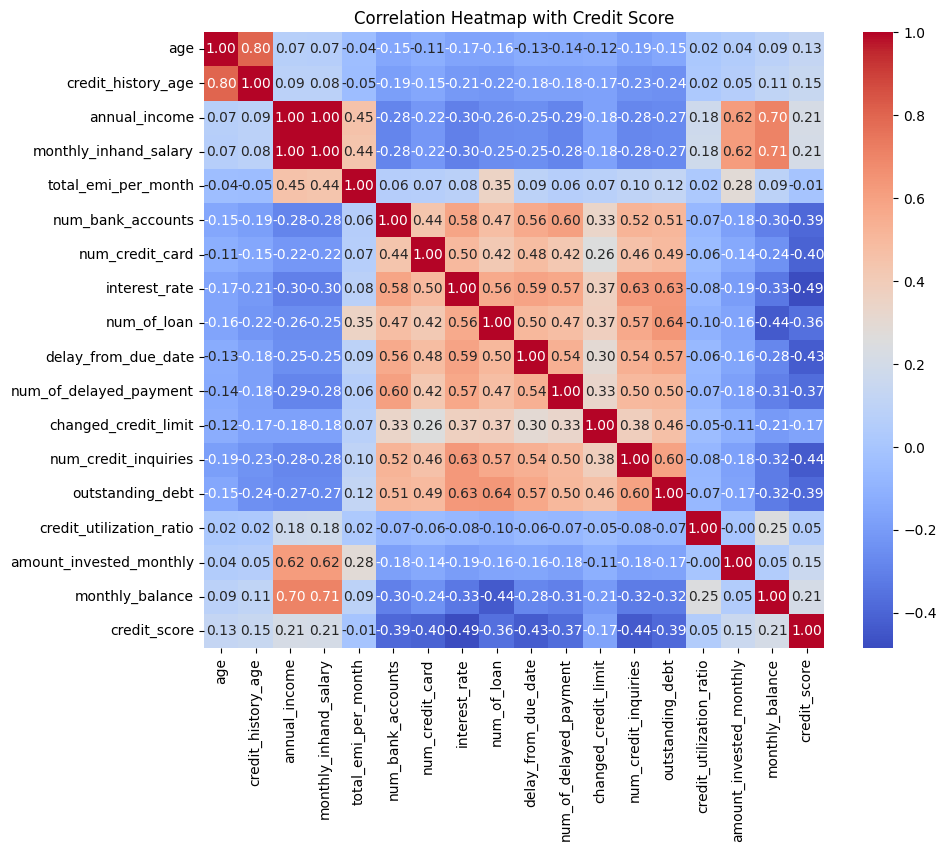

In [176]:
# Select only numeric columns from the DataFrame to compute correlations
numeric_df = df.select_dtypes(include="number")

# Set the figure size for better visualization
plt.figure(figsize=(10, 8))

# Calculate the correlation matrix for the numeric columns
correlation_matrix = numeric_df.corr()

# Plot the heatmap to visualize correlations
sns.heatmap(
    correlation_matrix,          # The correlation matrix to plot
    annot=True,                  # Show correlation values on the heatmap
    cmap='coolwarm',             # Use a diverging colormap to highlight differences
    fmt='.2f'                    # Format the correlation values to 2 decimal places
)

# Add a title to the plot
plt.title("Correlation Heatmap with Credit Score")

# Display the heatmap
plt.show()

This correlation heatmap shows the relationship between various financial and demographic variables with the credit score. The correlation coefficient ranges between -1 and +1. The closer the value is to **+1**, the stronger the **positive relationship**; the closer it is to **-1**, the stronger the **negative relationship**. Values near zero indicate a weak or no relationship.

### **Insights:**

#### **1. Variables with the Strongest Negative Correlation with Credit Score**  
These variables tend to decrease the credit score:  
- **`credit_utilization_ratio` (-0.53):** The credit utilization ratio has the strongest negative correlation with the credit score. As the credit utilization increases, the credit score decreases, indicating that higher credit usage is associated with financial risk.  
- **`num_of_delayed_payment` (-0.42):** The number of delayed payments significantly negatively impacts the credit score. More delayed payments result in a lower credit score.  
- **`outstanding_debt` (-0.39):** As the amount of outstanding debt increases, the credit score decreases. This suggests that individuals struggling with unpaid debts tend to have lower credit scores.

#### **2. Variables with the Strongest Positive Correlation with Credit Score**  
These variables tend to increase the credit score:  
- **`monthly_inhand_salary` (+0.39):** Monthly in-hand salary has a moderately positive relationship with the credit score. Higher salaries indicate a better credit score.  
- **`num_credit_card` (+0.24):** The number of credit cards held shows a positive correlation. Responsible use of credit cards can improve the credit score.  
- **`credit_history_age` (+0.29):** The age of credit history has a positive relationship with the credit score. Individuals with a longer credit history generally have higher credit scores.

#### **3. Variables with Weak or Insignificant Correlation**  
The following variables have a weak relationship with the credit score:  
- **`age` (+0.14):** Age has a very weak positive relationship with the credit score.  
- **`total_emi_per_month` (+0.11):** The total monthly EMI payments have a weak positive correlation with the credit score.  
- **`num_bank_accounts` (-0.04):** The number of bank accounts has almost no effect on the credit score.

---

### **General Observations:**  
1. **Negative Influences**: The most significant factors that decrease the credit score are the **credit utilization ratio**, **number of delayed payments**, and **outstanding debt**. These factors highlight financial instability.  
2. **Positive Influences**: Higher salaries, having more credit cards, and a longer credit history positively impact the credit score.  
3. **Key Factors**: For building a machine learning model, **`credit_utilization_ratio`**, **`num_of_delayed_payment`**, and **`outstanding_debt`** should be prioritized as the most important variables.  
4. **Low-Impact Factors**: Variables like age and the number of bank accounts are of secondary importance in the analysis.

Based on this information, critical factors can be selected to develop an effective credit score classification model.

In [177]:
# Select all numeric columns from the DataFrame except the last one (usually the target column)
numeric_columns = df.select_dtypes(include=[np.number]).columns[:-1]

# Display the list of numeric columns (excluding the target column)
numeric_columns

Index(['age', 'credit_history_age', 'annual_income', 'monthly_inhand_salary',
       'total_emi_per_month', 'num_bank_accounts', 'num_credit_card',
       'interest_rate', 'num_of_loan', 'delay_from_due_date',
       'num_of_delayed_payment', 'changed_credit_limit',
       'num_credit_inquiries', 'outstanding_debt', 'credit_utilization_ratio',
       'amount_invested_monthly', 'monthly_balance'],
      dtype='object')

In [183]:
# Credit_Mix: Bad = 0, Standard = 1, Good = 2
credit_mix_mapping = {
    'Bad': 0,
    'Standard': 1,
    'Good': 2
}

df4['credit_mix'].map(credit_mix_mapping)
df_cat['credit_mix'] = df4['credit_mix'].map(credit_mix_mapping)


In [184]:
# Payment_of_Min_Amount: No = 0, Yes = 1, NM (No Mention) = -1
payment_min_mapping = {
    'No': 0,
    'Yes': 1,
    # 'NM': -1
}
df_cat['payment_of_min_amount'] = df4['payment_of_min_amount'].map(payment_min_mapping)


In [185]:
# Payment_Behaviour: mã hóa 6 nhóm cụ thể
payment_behaviour_mapping = {
    'High_spent_Large_value_payments': 0,
    'High_spent_Medium_value_payments': 1,
    'High_spent_Small_value_payments': 2,
    'Low_spent_Large_value_payments': 3,
    'Low_spent_Medium_value_payments': 4,
    'Low_spent_Small_value_payments': 5
}
df_cat['payment_behaviour'] = df4['payment_behaviour'].map(payment_behaviour_mapping)


In [186]:
df_cat

,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,No Loan,Not Specified,Payday Loan,Personal Loan,Student Loan,credit_mix,payment_of_min_amount,payment_behaviour
0,1,1,0,1,0,0,0,0,1,0,2,0,2
1,1,1,0,1,0,0,0,0,1,0,2,0,3
2,1,1,0,1,0,0,0,0,1,0,2,0,4
3,1,1,0,1,0,0,0,0,1,0,2,0,5
4,1,1,0,1,0,0,0,0,1,0,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,0,0,0,0,0,0,0,0,1,2,0,0
99996,1,0,0,0,0,0,0,0,0,1,2,0,1
99997,1,0,0,0,0,0,0,0,0,1,2,0,0
99998,1,0,0,0,0,0,0,0,0,1,2,0,3


In [187]:
def remove_highly_correlated_features(df, threshold=0.9):
    # Chỉ lấy các cột số
    corr_matrix = df.corr(numeric_only=True).abs()

    # Lấy upper triangle (tam giác trên) để tránh trùng lặp
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Tìm các cột có tương quan lớn hơn ngưỡng
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    print(f"Các cột bị loại do tương quan cao (> {threshold}): {to_drop}")
    df = df.drop(columns=to_drop)

remove_highly_correlated_features(df)

Các cột bị loại do tương quan cao (> 0.9): ['monthly_inhand_salary']
